## HW 3: Q-learning
_Reference: based on Practical RL course by YSDA_

In this notebook you have to master Q-learning and apply it to RL problems once again.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to the template file and submit it to the Contest.


## ДЗ 3: Q-learning
Ссылка: основано на практическом курсе RL от YSDA_

В этой тетради вам предстоит освоить Q-learning и еще раз применить его к задачам RL.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## Step 1: Tabular Q-learning with SoftMax policy

We want you to implement Q-learning algorithm with softmax policy.

You need to implement QLearningAgent (follow instructions for each method) and use it on a number of tests below.

SoftMax policy means that actions probabilities are computed from q-values using softmax function, where $\tau$ is the softmax temperature:

$$ \pi(a_i \mid s) = \operatorname{softmax} \left( \left\{ {Q(s, a_j) \over \tau} \right\}_{j=1}^n \right)_i = {\operatorname{exp} \left( Q(s,a_i) / \tau \right)  \over {\sum_{j}  \operatorname{exp} \left( Q(s,a_j) / \tau  \right)}} $$


## Шаг 1: Табличное Q-обучение с помощью политики SoftMax

Мы хотим, чтобы вы внедрили алгоритм Q-обучения с помощью политики softmax.

Вам необходимо внедрить QLearningAgent (следуйте инструкциям для каждого метода) и использовать его в ряде тестов, приведенных ниже.

Политика SoftMax означает, что вероятности действий вычисляются на основе значений q с использованием функции softmax, где $\tau$ - температура softmax:

$$ \pi(a_i \mid s) = \operatorname{softmax} \left( \left\{ {Q(s, a_j) \over \tau} \right\}_{j=1}^n \right)_i = {\operatorname{exp} \left( Q(s,a_i) / \tau \right)  \over {\sum_{j}  \operatorname{exp} \left( Q(s,a_j) / \tau  \right)}} $$

First, implement softmax. Do not forget that exponent of large value might be too big to fit in float. Substract maximum for numerical stability.

Сначала реализуйте softmax. Не забывайте, что показатель степени с большим значением может быть слишком большим, чтобы поместиться в float. Вычтите максимум для числовой стабильности.

In [4]:
def my_softmax(values: np.ndarray, T=1.):
    # Вычитаем максимум для численной стабильности
    scaled_values = values / T
    shifted_values = scaled_values - np.max(scaled_values)
    exp_values = np.exp(shifted_values)
    probas = exp_values / np.sum(exp_values)
    return probas

Now check your Softmax using the following tests.  

Теперь проверьте свой Softmax с помощью следующих тестов.

In [5]:
import torch
test_data = np.arange(5)
for temp in [0.1, 0.5, 1, 5]:
  local_softmax = my_softmax(test_data, T=temp)
  with torch.no_grad():
    torch_softmax = torch.softmax(torch.from_numpy(test_data)/temp, dim=-1)
  assert np.allclose(local_softmax, torch_softmax.numpy())
  print(f'Passed for temp={temp}')

Passed for temp=0.1
Passed for temp=0.5
Passed for temp=1
Passed for temp=5


Простая визуализация для вашего удобства

Text(0.5, 1.0, 'Example softmax with temp = 1')

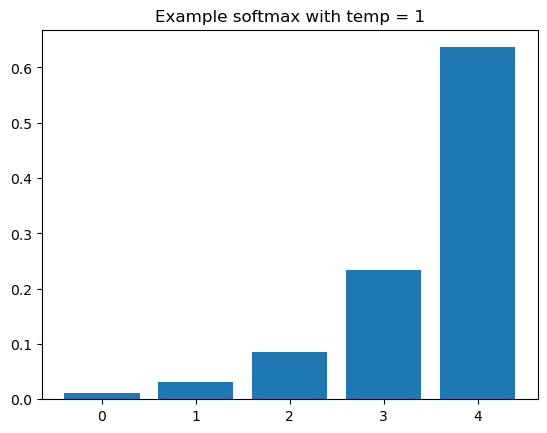

In [6]:
temp = 1
plt.bar(test_data, my_softmax(test_data, T=temp))
plt.title(f'Example softmax with temp = {temp}')

Now implement the `QLearningAgent`. You will solve several environments using it and later submit to the Contest.  
Теперь реализуйте "QLearningAgent". С его помощью вы решите несколько задач, а затем подадите заявку на участие в конкурсе.

In [7]:
import random
from collections import defaultdict
import numpy as np

class QLearningAgent:
    def __init__(self, alpha, discount, get_legal_actions, temp=1.):
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.discount = discount
        self.temp = temp

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return 0.0

        # Вычисляем максимальное Q-значение среди всех возможных действий
        q_values = [self.get_qvalue(state, action) for action in possible_actions]
        value = max(q_values)
        
        return value

    def update(self, state, action, reward, next_state):
        gamma = self.discount
        learning_rate = self.alpha
        
        # Текущее Q-значение
        current_q = self.get_qvalue(state, action)
        # Q-значение для следующего состояния
        next_value = self.get_value(next_state)
        # Формула обновления Q-обучения
        qvalue = (1 - learning_rate) * current_q + learning_rate * (reward + gamma * next_value)
        
        self.set_qvalue(state, action, qvalue)

    def get_best_action(self, state):
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None

        # Находим действие с максимальным Q-значением
        best_action = None
        best_value = float('-inf')
        
        for action in possible_actions:
            q_value = self.get_qvalue(state, action)
            if q_value > best_value:
                best_value = q_value
                best_action = action
        
        return best_action

    def get_softmax_policy(self, state):
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None

        # Получаем Q-значения для всех действий
        q_values = np.array([self.get_qvalue(state, action) for action in possible_actions])
        
        # Применяем softmax с температурой
        scaled_values = q_values / self.temp
        shifted_values = scaled_values - np.max(scaled_values)  # Для численной стабильности
        exp_values = np.exp(shifted_values)
        probabilities = exp_values / np.sum(exp_values)
        
        return dict(zip(possible_actions, probabilities))

    def get_action(self, state):
        possible_actions = self.get_legal_actions(state)
        
        if len(possible_actions) == 0:
            return None

        # Получаем вероятности действий через softmax политику
        action_probs = self.get_softmax_policy(state)
        
        # Преобразуем в список вероятностей в том же порядке, что и possible_actions
        prob_list = [action_probs[action] for action in possible_actions]
        
        # Выбираем действие согласно распределению вероятностей
        chosen_action = np.random.choice(possible_actions, p=prob_list)
        
        return chosen_action

- `get_value(state)`: Вычисляет значение состояния как максимальное Q-значение среди всех возможных действий.
- `update(state, action, reward, next_state)`: Реализует формулу обновления Q-обучения: Q(s,a) = (1 - α) * Q(s,a) + α * (r + γ * max_a' Q(s',a'))
- `get_best_action(state)`: Возвращает действие с максимальным Q-значением для данного состояния.
- `get_softmax_policy(state)`: Вычисляет вероятности действий по формуле softmax с учетом температуры.
- `get_action(state)`: Выбирает действие согласно softmax политике, используя np.random.choice с заданными вероятностями.

### Try it on taxi

Here we use the Q-Learning agent on the Taxi-v3 environment from OpenAI gym.
You will need to complete a few of its functions.

### Попробуйте это в taxi

Здесь мы используем Q-Learning agent в среде Taxi-v3 от OpenAI gym.
Вам нужно будет выполнить несколько его функций.

In [8]:
import gymnasium as gym

env = gym.make("Taxi-v3", render_mode="rgb_array")

n_actions = env.action_space.n

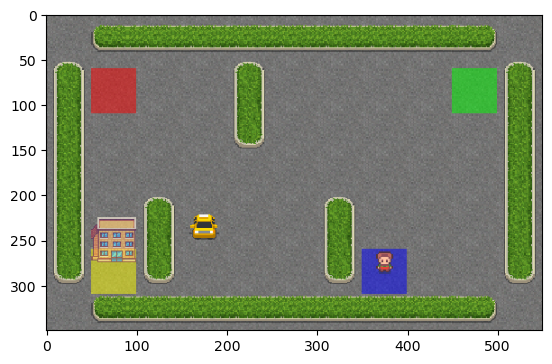

In [9]:
s, _ = env.reset()
plt.imshow(env.render())

In [10]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [11]:
def play_and_train(env, agent, t_max=10**4):
    """
    This function should
    - run a full game, actions given by agent's e-greedy policy
    - train agent using agent.update(...) whenever it is possible
    - return total reward
    """
    total_reward = 0.0
    s, _ = env.reset()

    for t in range(t_max):
        # get agent to pick action given state s.
        a = agent.get_action(s)

        next_s, r, done, _, _ = env.step(a)

        # train (update) agent for state s
        agent.update(s, a, r, next_s)

        s = next_s
        total_reward += r
        if done:
            break

    return total_reward

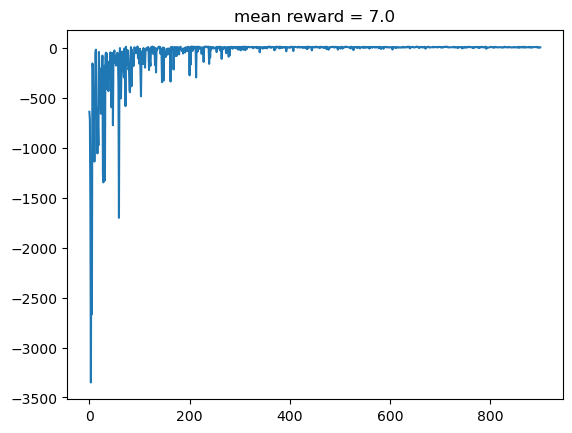

In [12]:
from IPython.display import clear_output

rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))

    if i % 100 == 0:
        clear_output(True)
        plt.title("mean reward = {:.1f}".format(np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.show()

# Step 2: Discretized state spaces.

Let's try solving the same `CartPole-v1` problem using Tabular Q-learning.

This environment has a continuous set of possible states, so we will have to group them into bins somehow.

Simple binarization is already present. You can play with to see what happens.

The simplest way is to use `round(x, n_digits)` (or `np.round`) to round a real number to a given amount of digits. The tricky part is to get the `n_digits` right for each state to train effectively.

Note that you don't need to convert state to integers, but to __tuples__ of any kind of values.


# Шаг 2: Дискретизированные пространства состояний.

Давайте попробуем решить ту же задачу "CartPole-v1" с помощью табличного Q-обучения.

Эта среда имеет непрерывный набор возможных состояний, поэтому нам придется каким-то образом сгруппировать их по ячейкам.

Простая бинаризация уже присутствует. Вы можете поиграть, чтобы посмотреть, что получится.

Самый простой способ - использовать `round(x, n_digits)` (или `np.round`) для округления действительного числа до заданного количества цифр. Сложная часть заключается в том, чтобы правильно задать n_значений для каждого состояния для эффективного обучения.

Обратите внимание, что вам не нужно преобразовывать состояние в целые числа, а в __кортежи__ любых значений.

In [ ]:
def make_env():
    return gym.make("CartPole-v1", render_mode="rgb_array")


env = make_env()
n_actions = env.action_space.n

print("first state: %s" % (env.reset()[0]))
plt.imshow(env.render())

### Play a few games

We need to estimate observation distributions. To do so, we'll play a few games and record all states.


### Сыграем в несколько игр

Нам нужно оценить распределение наблюдений. Для этого мы сыграем в несколько игр и запишем все состояния.

In [15]:
def visualize_cartpole_observation_distribution(seen_observations):
    # Преобразуем список массивов в 2D numpy array
    seen_observations = np.array(seen_observations)
    
    # Проверяем форму массива
    print(f"Shape of observations: {seen_observations.shape}")
    
    # The meaning of the observations is documented in
    # https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

    f, axarr = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
    titles = ["Cart Position", "Cart Velocity", "Pole Angle", "Pole Velocity At Tip"]
    
    for i, title in enumerate(titles):
        ax = axarr[i // 2, i % 2]
        # Проверяем, что у нас достаточно измерений
        if seen_observations.ndim > 1 and seen_observations.shape[1] > i:
            ax.hist(seen_observations[:, i], bins=20)
        else:
            # Если данные одномерные, используем все данные для первого графика
            if i == 0:
                ax.hist(seen_observations, bins=20)
            else:
                ax.text(0.5, 0.5, 'No data', horizontalalignment='center', 
                       verticalalignment='center', transform=ax.transAxes)
        ax.set_title(title)
        xmin, xmax = ax.get_xlim()
        ax.set_xlim(min(xmin, -xmax), max(-xmin, xmax))
        ax.grid()
    f.tight_layout()

Shape of observations: (2533833,)


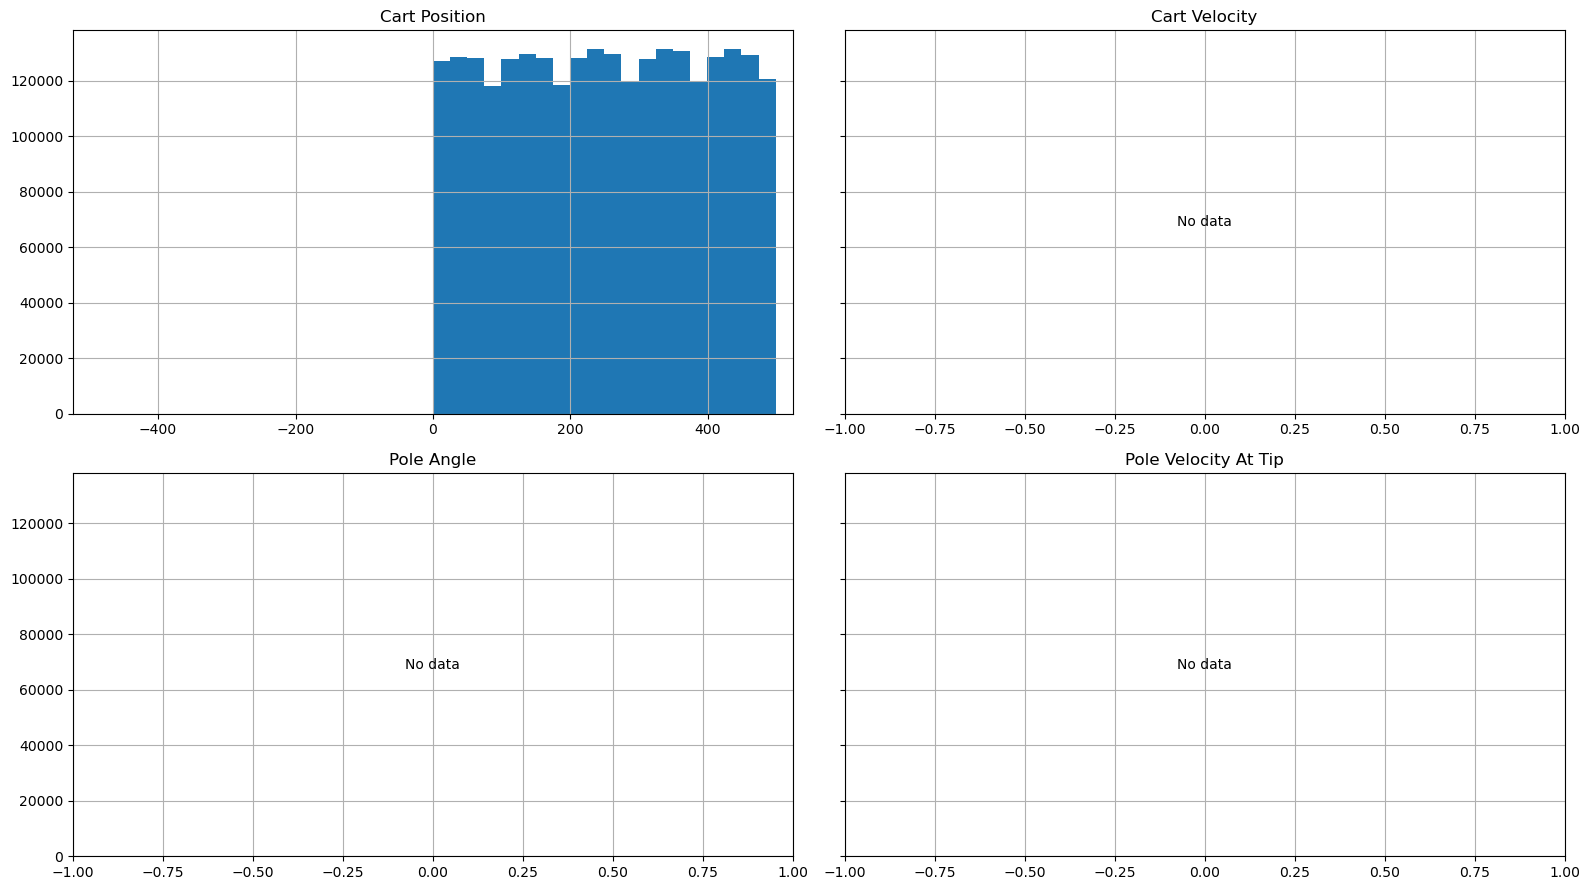

In [16]:
# Собираем наблюдения
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)

visualize_cartpole_observation_distribution(seen_observations)

## Discretize environment
## Дискретизация окружающей среды

In [20]:
def make_env():
    return gym.make("CartPole-v1", render_mode="rgb_array")

class Discretizer(ObservationWrapper):
    def observation(self, state):
        # Hint: you can do that with round(x, n_digits).
        # You may pick a different n_digits for each dimension.
        
        # Создаем копию состояния, чтобы не изменять оригинал
        discretized_state = state.copy()
        features_ndigits = [1, 1, 1, 1]
        
        for feature_index in range(len(discretized_state)):
            discretized_state[feature_index] = round(discretized_state[feature_index], features_ndigits[feature_index])
        
        return tuple(discretized_state)

In [21]:
# Теперь создаем среду с дискретизатором
env = Discretizer(make_env())

Shape of observations: (23172, 4)


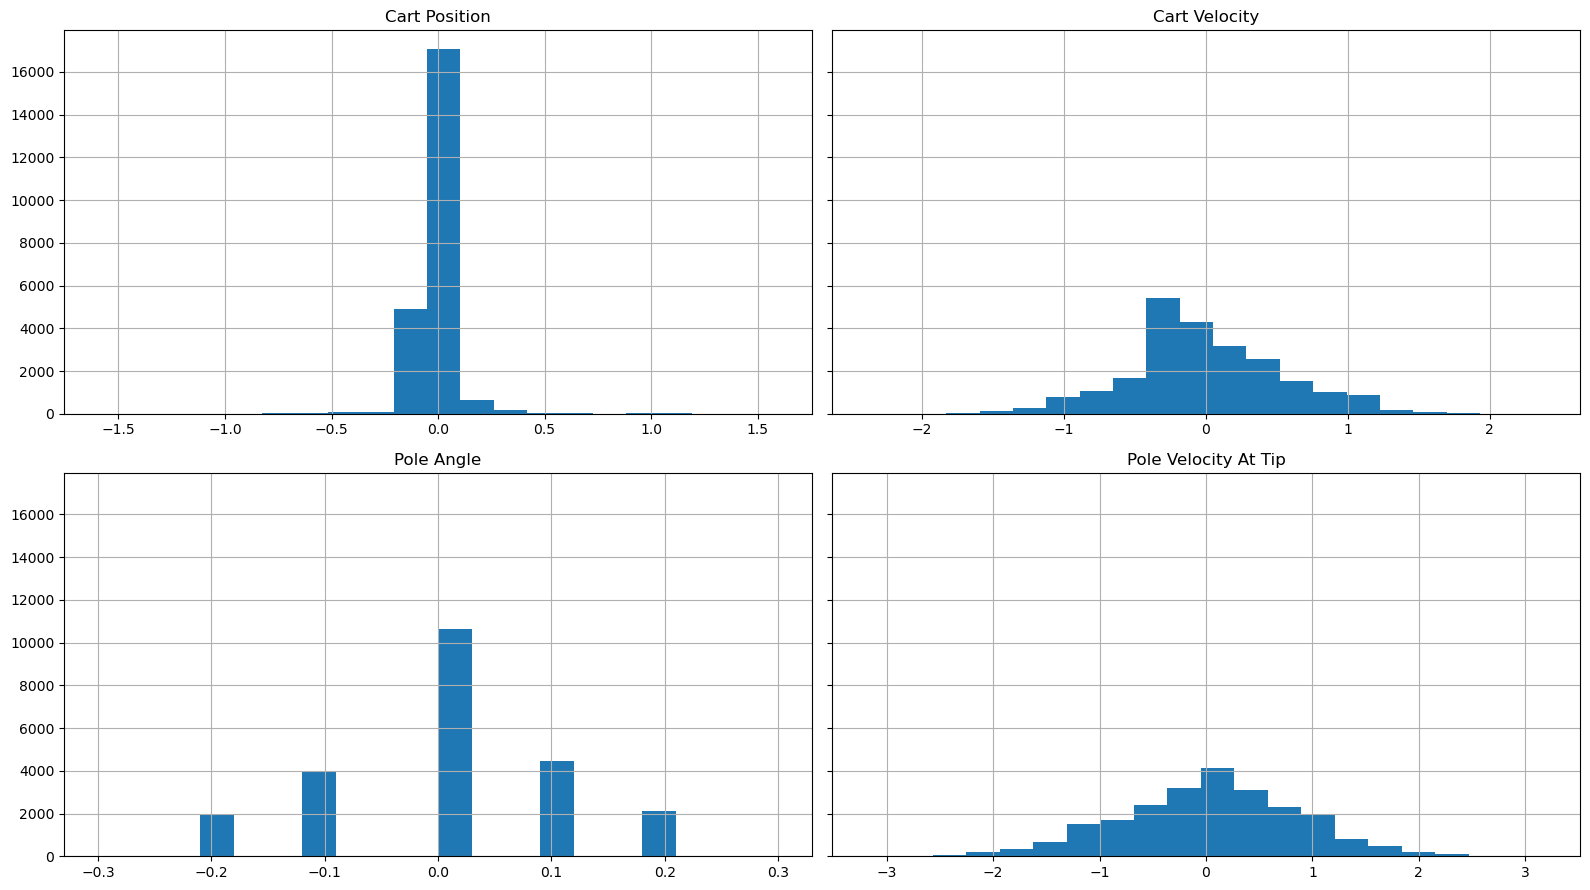

In [22]:
seen_observations = []
for _ in range(1000):
    s, _ = env.reset()
    seen_observations.append(s)
    done = False
    while not done:
        s, r, done, _, _ = env.step(env.action_space.sample())
        seen_observations.append(s)
        if done:
            break

visualize_cartpole_observation_distribution(seen_observations)

## Learn discretized policy

Now let's train a policy that uses discretized state space.

__Tips:__

* Note that increasing the number of digits for one dimension of the observations increases your state space by a factor of $10$.
* If your discretization is too fine-grained, your agent will take much longer than 10000 steps to converge. You can either increase the number of iterations and reduce epsilon decay or change discretization. In practice we found that this kind of mistake is rather frequent.
* If your discretization is too coarse, your agent may fail to find the optimal policy. In practice we found that on this particular environment this kind of mistake is rare.
* **Start with a coarse discretization** and make it more fine-grained if that seems necessary.
* Having $10^3$–$10^4$ distinct states is recommended (`len(agent._qvalues)`), but not required.
* If things don't work without annealing $\varepsilon$, consider adding that, but make sure that it doesn't go to zero too quickly.

A reasonable agent should attain an average reward of at least 50.

## Изучите дискретизированную политику

Теперь давайте разработаем политику, которая использует дискретизированное пространство состояний.

__Tips:__

* Обратите внимание, что увеличение количества цифр для одного измерения наблюдений увеличивает ваше пространство состояний в 10 раз.
* Если ваша дискретизация слишком мелкозернистая, вашему агенту потребуется гораздо больше времени, чем 10000 шагов для сходимости. Вы можете либо увеличить количество итераций и уменьшить затухание эпсилон, либо изменить дискретизацию. На практике мы обнаружили, что такого рода ошибки встречаются довольно часто.
* Если ваша дискретизация слишком грубая, ваш агент может не суметь найти оптимальную политику. На практике мы обнаружили, что в данной конкретной среде такого рода ошибки случаются редко.
* ** Начните с грубой дискретизации ** и сделайте ее более детализированной, если это кажется необходимым.
* Рекомендуется использовать $10^3$–$10^4$ различные состояния (`len(agent._qvalues)`), но не обязательно.
* Если что-то не получается без отжига $\varepsilon$, подумайте о том, чтобы добавить это, но убедитесь, что оно не обнулится слишком быстро.

Разумный агент должен получать среднее вознаграждение не менее 50.

In [23]:
import pandas as pd


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values

In [24]:
agent = QLearningAgent(alpha=0.5, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [25]:
rewards = []

In [26]:
for i in range(5000):
    reward = play_and_train(env, agent)
    rewards.append(reward)

    if i % 100 == 0:
        rewards_ewma = moving_average(rewards)

        clear_output(True)
        plt.plot(rewards, label="rewards")
        plt.plot(rewards_ewma, label="rewards ewma@100")
        plt.legend()
        plt.grid()
        plt.title("rewards ewma@100 = {:.1f}".format(rewards_ewma[-1]))
        plt.show()

AssertionError: 3 (<class 'numpy.int64'>) invalid

In [ ]:
print("Your agent has learned {} Q-values.".format(len(agent._qvalues)))

## Step 3: EV-SARSA with softmax policy

The policy we're going to use is still softmax, but now the state  value is computed differently.

We inherit from the existing implementation of `QLearningAgent` and only update the `get_value` method.

In [ ]:
class EVSarsaAgent(QLearningAgent):
    """
    An agent that changes some of q-learning functions to implement Expected Value SARSA.
    Note: this demo assumes that your implementation of QLearningAgent.update uses get_value(next_state).
    If it doesn't, please add
        def update(self, state, action, reward, next_state):
            and implement it for Expected Value SARSA's V(s')
    """

    def get_value(self, state):
        """
        Returns Vpi for current state under the softmax policy:
          V_{pi}(s) = sum _{over a_i} {pi(a_i | s) * Q(s, a_i)}

        Hint: all other methods from QLearningAgent are still accessible.
        """
        possible_actions = self.get_legal_actions(state)
        # If there are no legal actions, return 0.0
        if len(possible_actions) == 0:
            return 0.0

        # YOUR CODE HERE
        # Compute the value of the current state under the softmax policy.
        value = None
        assert value is not None

        return value

### Cliff World

Let's now see how our algorithm compares against q-learning in case where we force agent to explore all the time.

<img src=https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/cliffworld.png width=600>
<center><i>Image from CS188</i></center>

In [ ]:
env = gym.make("CliffWalking-v1", render_mode="rgb_array")
n_actions = env.action_space.n

In [ ]:
# Our cliffworld has one difference from what's in the image: there is no wall.
# Agent can choose to go as close to the cliff as it wishes.
# x:start, T:exit, C:cliff, o: flat ground

env.reset()
plt.imshow(env.render())

In [ ]:
agent_sarsa = EVSarsaAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

agent_ql = QLearningAgent(alpha=0.25, discount=0.99, get_legal_actions=lambda s: range(n_actions))

In [ ]:
from IPython.display import clear_output


def moving_average(x, span=100):
    return pd.DataFrame({"x": np.asarray(x)}).x.ewm(span=span).mean().values


rewards_sarsa, rewards_ql = [], []

for i in range(5000):
    rewards_sarsa.append(play_and_train(env, agent_sarsa))
    rewards_ql.append(play_and_train(env, agent_ql))

    if i % 100 == 0:
        clear_output(True)
        print("EVSARSA mean reward =", np.mean(rewards_sarsa[-100:]))
        print("QLEARNING mean reward =", np.mean(rewards_ql[-100:]))
        plt.plot(moving_average(rewards_sarsa), label="ev_sarsa")
        plt.plot(moving_average(rewards_ql), label="qlearning")
        plt.grid()
        plt.legend()
        plt.ylim(-500, 0)
        plt.show()

Let's now see what did the algorithms learn by visualizing their actions at every state.

In [ ]:
def draw_policy(agent):
    """Prints CliffWalkingEnv policy with arrows. Hard-coded."""

    env = gym.make("CliffWalking-v1", render_mode="ansi")
    env.reset()
    grid = [x.split("  ") for x in env.render().split("\n")[:4]]

    n_rows, n_cols = 4, 12
    start_state_index = 36
    actions = "^>v<"

    for yi in range(n_rows):
        for xi in range(n_cols):
            if grid[yi][xi] == "C":
                print(" C ", end="")
            elif (yi * n_cols + xi) == start_state_index:
                print(" X ", end="")
            elif (yi * n_cols + xi) == n_rows * n_cols - 1:
                print(" T ", end="")
            else:
                print(" %s " % actions[agent.get_best_action(yi * n_cols + xi)], end="")
        print()

In [ ]:
print("Q-Learning")
draw_policy(agent_ql)

print("SARSA")
draw_policy(agent_sarsa)

Congratulations! Finally, copy the `QLearningAgent`, `EVSarsaAgent` and `my_softmax` to the template and submit them to the Contest.

Good luck!